***CS5004 DQN CartPole Classic Control AY 24/25***

This sample code is based on one of the recommended texts. A small number of errors were deliberately injected into the code.

If using this code as a basis for Assignment 3
•	Correct the bugs.
•	Comment the code extensively.
•	Replace CartPole with a different Classic Control problem form gym.
•	Generate more informative plots i.e. plot running average.
•	Consider generating an animation.
•	Play around with hyperparameters and parameters to achieve ‘satisfactory’ performance.

A template will NOT be provided for Task 4. Use this and modify the following (1) shape of obs and actions (2) network structure, (3) processing of experience, etc.

*** Based on the code from Chapter 18 Reinforcement Learning by Aurelin Geron.***
Make sure you are using the 3rd Edition!
And the code is from
https://github.com/ageron



This project requires Python 3.10 or above:

In [1]:
import sys
assert sys.version_info >= (3, 10)

from packaging import version
import tensorflow as tf
assert version.parse(tf.__version__) >= version.parse("2.8.0")

import matplotlib.animation
import matplotlib.pyplot as plt

**Warning**: the latest TensorFlow versions are based on Keras 3. For chapters 10-15, it wasn't too hard to update the code to support Keras 3, but unfortunately it's much harder for this chapter, in particular adding custom losses using the functional API is not implemented yet. So for this chapter I've had to revert to Keras 2. To do that, I set the `TF_USE_LEGACY_KERAS` environment variable to `"1"` and import the `tf_keras` package. This ensures that `tf.keras` points to `tf_keras`, which is Keras 2.*.

***Important notes ref Gymnasium Library:***

OpenAI has handed over the maintenance and developmnent of the Gym library to the Farama foundation and it was renamed to Gymnasium. It's a drop-in replacement for OpenAI Gym: you can just install gymnasium instead of gym, and import gymnasium as gym, and everything should work fine.
by running the following cell, you accept the Atari ROM license.

In [2]:
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    import os
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

In [3]:
if "google.colab" in sys.modules or "kaggle_secrets" in sys.modules:
    %pip install -q -U gymnasium swig
    %pip install -q -U gymnasium[classic_control,box2d,atari]

import gymnasium as gym

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 56.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 23.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


And TensorFlow ≥ 2.8:

Define the default font sizes for plots.

In [4]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')

And the implementation for saving figures to a specific folder `images/rl` folder.

In [5]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "rl"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Check for GPU

In [6]:
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if "google.colab" in sys.modules:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if "kaggle_secrets" in sys.modules:
        print("Go to Settings > Accelerator and select GPU.")

# Introduction to Gymnasium

In [7]:
import gymnasium as gym

# Create the environment
env = gym.make("LunarLander-v3", render_mode="rgb_array")


The LunarLander-v3 environment consists of a spacecraft that must land safely on a designated landing pad. The agent controls the lander by firing thrusters to adjust its position, velocity, and angle. The objective is to land the spacecraft smoothly while minimizing fuel usage and avoiding crashes.

Each observation is a 1D NumPy array composed of 8 floats:

X Position → Horizontal position of the lander.
Y Position → Vertical position of the lander.
X Velocity → Speed of the lander in the horizontal direction.
Y Velocity → Speed of the lander in the vertical direction.
Angle → Orientation of the lander (0 = perfectly upright).
Angular Velocity → How fast the lander is rotating.
Left Leg Contact → 1 if the left leg touches the ground, else 0.
Right Leg Contact → 1 if the right leg touches the ground, else 0.
There are four possible actions:

0 → Do nothing (no thrust).
1 → Fire left thruster (push right).
2 → Fire main thruster (push up).
3 → Fire right thruster (push left).
The agent must control the thrusters to land safely on the landing pad while minimizing fuel consumption and avoiding crashes. The environment provides rewards for smooth landings and penalties for crashes or excessive fuel usage.

From an RL point of view:

The agent is the spaceship.

The environment is the lunar surface.

The state includes position, velocity, and angle.

The actions include firing left, right, or no thrusters.

The reward is based on how well the agent lands.

The lunar lander has a lot of cases for reward. this will make it easier to train. Sparse reward problems like the mountain car can require an extortionate amount of training and stability tuning in order to achieve good results.

**Tip**: `gym.envs.registry` is a dictionary containing all available environments:

In [8]:
# extra code – shows the first few environments
envs = gym.envs.registry
sorted(envs.keys())[:5] + ["..."]

['Acrobot-v1', 'Ant-v2', 'Ant-v3', 'Ant-v4', 'Ant-v5', '...']

The registry values are environment specifications:

In [9]:
spec = gym.spec("LunarLander-v3")
print(spec)


EnvSpec(id='LunarLander-v3', entry_point='gymnasium.envs.box2d.lunar_lander:LunarLander', reward_threshold=200, nondeterministic=False, max_episode_steps=1000, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='LunarLander', version=3, additional_wrappers=(), vector_entry_point=None)


In [10]:
# Reset environment
obs, info = env.reset(seed=42)

# Print initial state
print("Observation:", obs)
print("Info:", info)


Observation: [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]
Info: {}


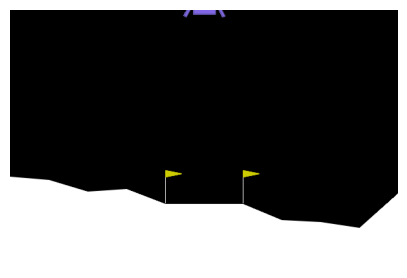

In [11]:
# extra code – creates a little function to render and plot an environment

def plot_environment(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img

plot_environment(env)
plt.show()

We are trying to stay within the flags.

In [12]:
env.action_space

action = 1  # accelerate right
obs, reward, done, truncated, info = env.step(action)
obs

array([ 0.00449829,  1.4247646 ,  0.22032492,  0.294843  , -0.00285054,
       -0.00391279,  0.        ,  0.        ], dtype=float32)

The environment also tells the agent how much reward it got during the last step:

In [13]:
reward
done
truncated
info

{}

In [14]:
if done or truncated:
    obs, info = env.reset()

# Deep Q-Network

In [15]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on the CPU

input_shape = [8]  # LunarLander-v2 has 8 state variables
n_outputs = 4  # == env.action_space.n

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="elu", input_shape=input_shape, kernel_initializer="he_normal"),
    tf.keras.layers.Dense(32, activation="elu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(n_outputs)
])

def epsilon_greedy_policy(state, epsilon=0):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)  # random action
    else:
        Q_values = model.predict(state[np.newaxis], verbose=0)[0]
        return Q_values.argmax()  # optimal action according to the DQN




Create a target model to try to stabilize learning

In [16]:
#  Create the Target Model (Copy of Main Model)
target_model = tf.keras.models.clone_model(model)
target_model.set_weights(model.get_weights())  # Copy initial weights


In [17]:
# extra code – A basic circular buffer implementation

from collections import deque

replay_buffer = deque(maxlen=2000)

def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]
    return [
        np.array([experience[field_index] for experience in batch])
          for field_index in range(6)
    ]  # [states, actions, rewards, next_states, dones, truncateds]

Now we can create a function that will use the DQN to play one step, and record its experience in the replay buffer:

In [18]:
def play_one_step(env, state, epsilon):
    action = epsilon_greedy_policy(state, epsilon)
    next_state, reward, done, truncated, info = env.step(action)
    replay_buffer.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated, info

Lastly, let's create a function that will sample some experiences from the replay buffer and perform a training step:

In [19]:
import numpy as np

In [20]:
# extra code – for reproducibility, and to generate the next figure
env.reset(seed=42)
np.random.seed(42)
tf.random.set_seed(42)
rewards = []
best_score = 0

In [21]:
batch_size = 64
discount_factor = 0.95
optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-3)
loss_fn = tf.keras.losses.mean_squared_error

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones, truncateds = experiences
    #next_Q_values = model.predict(next_states, verbose=0)
    next_Q_values = target_model.predict(next_states, verbose=0)
    max_next_Q_values = next_Q_values.max(axis=1) # Greedly policy
    runs = 1.0 - (dones | truncateds)  # episode is not done or truncated
    runs = 1.0 - dones  # No need for truncateds
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = target_Q_values.reshape(-1, 1)
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

In [22]:
def is_landed(state):
    return state[6] == 1 and state[7] == 1  # Both legs touching

And now, let's train the model!

In [24]:
q_values_log = []
rewards = []
epsilons

for episode in range(300):
    obs, info = env.reset()
    total_reward=0
    epsilon = 0.01 + (1.0 - 0.01) * np.exp(-episode / 600)
    epsilon = max(0.01, 1.0 - episode / 1000)
    # epsilon = 0.9
    epailons.append(epsilon)

    for step in range(4000): # 4000 steps is never reached
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        total_reward += reward  # Accumulate episode rewards
        if done or truncated:
            break
    # Store Q-values for analysis
    q_values = model.predict(obs[np.newaxis], verbose=0)[0]  # Get Q-values for current state
    q_values_log.append(q_values)

    # extra code – displays debug info, stores data for the next figure, and
    #              keeps track of the best model weights so far
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, Reward: {total_reward}, eps: {epsilon:.3f}",
          end="")
    # rewards.append(step)
    rewards.append(total_reward)
    if total_reward >= best_score:
        best_weights = model.get_weights()
        best_score = total_reward
        print(f"\n New High Score: {best_score:.2f}")

    if episode > 50:
        training_step(batch_size)

    # Update Target Network every 5 episodes
    if episode % 10 == 0:
        target_model.set_weights(model.get_weights())

model.set_weights(best_weights)  # extra code – restores the best model weights

Episode: 227, Steps: 1000, Reward: 63.321410054507595, eps: 0.774
 New High Score: 63.32
Episode: 300, Steps: 98, Reward: -379.8106665903392, eps: 0.701

Epsilon decides

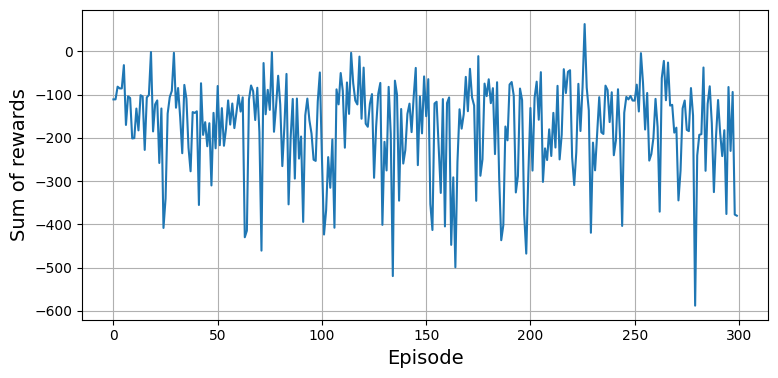

In [25]:
# extra code – this cell generates and saves Figure 18–10
plt.figure(figsize=(8, 4))
plt.plot(rewards)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
save_fig("dqn_ll_rewards_plot")
plt.show()

The model seems to get worse which suggests algorithm has some issues. It might be that it needs more time. It is not very stable at all.

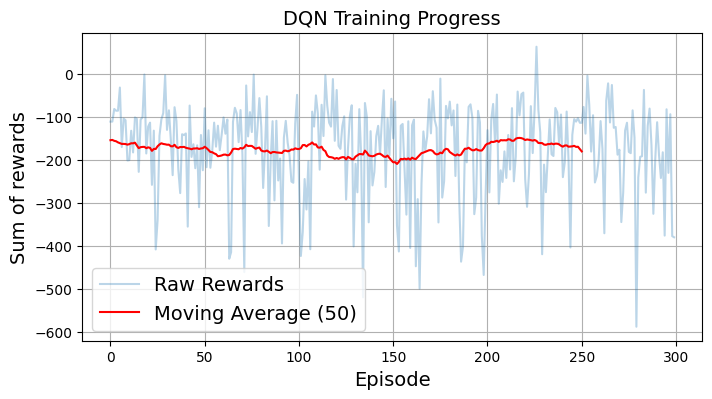

In [26]:
# Define moving average function
def moving_average(values, window_size=50):
    return np.convolve(values, np.ones(window_size)/window_size, mode='valid')

# Generate reward plot with moving average
plt.figure(figsize=(8, 4))
plt.plot(rewards, label="Raw Rewards", alpha=0.3)  # Original noisy rewards
plt.plot(moving_average(rewards, window_size=50), label="Moving Average (50)", color="red")
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.legend()
plt.grid(True)
plt.title("DQN Training Progress")

# Show plot
plt.show()


This is now displaying some learning.

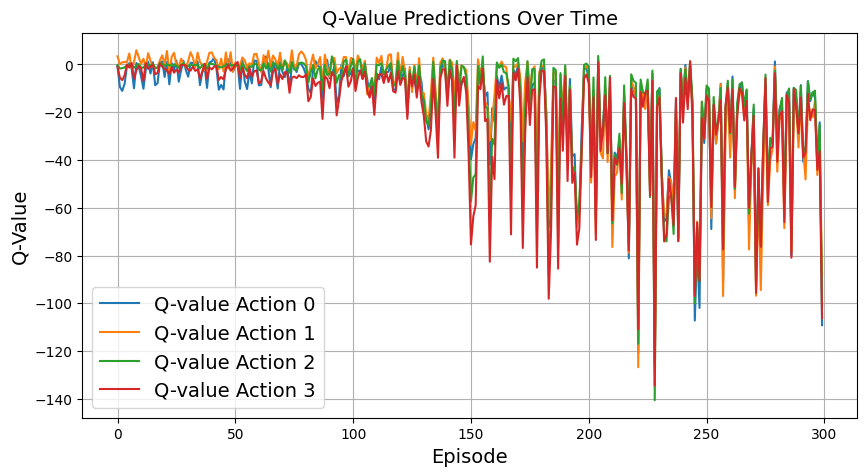

In [27]:
# Convert Q-values to NumPy array for plotting
q_values_log = np.array(q_values_log)

plt.figure(figsize=(10, 5))

# Plot Q-values for each action over episodes
for action in range(n_outputs):
    plt.plot(q_values_log[:, action], label=f"Q-value Action {action}")

plt.xlabel("Episode")
plt.ylabel("Q-Value")
plt.title("Q-Value Predictions Over Time")
plt.legend()
plt.grid()
plt.show()


In the early episodes the Q-values are stable and close to zero, as agent is still exploring.

They then decrease as agent learns actions resulting i lareg negative rewards.

Double DQN - using target network

In [28]:
def training_step_double_dqn(batch_size):
    """Performs experience replay and updates Q-values using Double DQN."""

    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones, truncateds = experiences

    # Double DQN: Use Online Network to Select Best Action in Next State
    best_actions = np.argmax(model.predict(next_states, verbose=0), axis=1)  # Online selects action

    # Double DQN: Use Target Network to Estimate Q-Value for Selected Action
    next_Q_values = target_model.predict(next_states, verbose=0)  # Target network gives Q-values
    max_next_Q_values = next_Q_values[np.arange(batch_size), best_actions]  # Get Q-value of chosen action

    # Only use future rewards if episode is not done
    runs = 1.0 - dones
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = target_Q_values.reshape(-1, 1)

    # Compute loss and apply gradients
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)  # Get Q-values from online network
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))



In [29]:
q_values_log = []
rewardsD = []
frames = []  # Store frames for animation

for episode in range(300):
    obs, info = env.reset()
    total_reward=0
    epsilon = 0.01 + (1.0 - 0.01) * np.exp(-episode / 600)
    epsilon = max(0.01, 1.0 - episode / 1000)
    # epsilon = 0.9
    for step in range(4000): # 4000 steps is never reached
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        total_reward += reward  # Accumulate episode rewards

        # Capture frame for animation
        frame = env.render()
        frames.append(frame)

        if done or truncated:
            break
    # Store Q-values for analysis
    q_values = model.predict(obs[np.newaxis], verbose=0)[0]  # Get Q-values for current state
    q_values_log.append(q_values)

    # extra code – displays debug info, stores data for the next figure, and
    #              keeps track of the best model weights so far
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, Reward: {total_reward}, eps: {epsilon:.3f}",
          end="")
    # rewards.append(step)
    rewardsD.append(total_reward)
    if total_reward >= best_score:
        best_weights = model.get_weights()
        best_score = total_reward
        print(f"\n New High Score: {best_score:.2f}")

    if episode > 50:
        training_step_double_dqn(batch_size)

    # Update Target Network every 50 episodes
    if episode % 50 == 0:
        target_model.set_weights(model.get_weights())

model.set_weights(best_weights)  # extra code – restores the best model weights

Episode: 300, Steps: 114, Reward: -94.21141977615427, eps: 0.701

KeyboardInterrupt: 

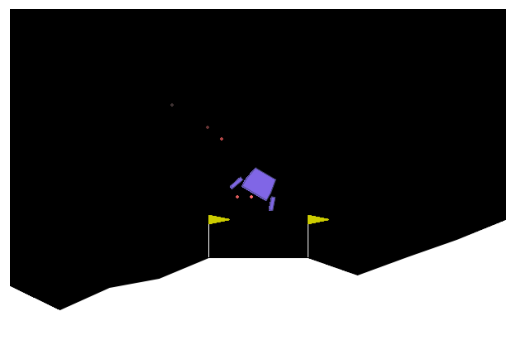

In [30]:
import matplotlib.animation as animation
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 50  # Increase to 50MB

# Close environment
env.close()

# Create animation
fig, ax = plt.subplots()
ax.axis("off")
frames = frames[::2]
im = ax.imshow(frames[0])

def update(frame):
    im.set_array(frames[frame])
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=50, blit=True)

# Display animation in Jupyter Notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

# Save animation as GIF (optional)
ani.save("lunar_landing.gif", writer="pillow", fps=30)

In [32]:
# extra code – this cell displays an animation of one episode

import matplotlib.pyplot as plt
import matplotlib.animation as animation

def update_scene(num, frames, patch):
    """Updates the frame in the animation."""
    patch.set_data(frames[num])
    return patch,

def plot_animation(frames, repeat=False, interval=40):
    """Displays an animation of frames using Matplotlib."""
    fig, ax = plt.subplots()
    patch = ax.imshow(frames[0], cmap='gray', interpolation='none')
    ax.axis('off')  # Remove axis for better visualization

    anim = animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)

    plt.close(fig)  # Prevent duplicate static figure display
    return anim

from IPython.display import HTML

# Example: Assuming `frames` is a list of NumPy arrays representing frames
anim = plot_animation(frames)
HTML(anim.to_jshtml())  # Display animation in Jupyter Notebook


KeyboardInterrupt: 

In [34]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def plot_animation(frames, skip=4, repeat=False, interval=40):
    """Displays an animation in Google Colab with reduced compute load."""

    frames = frames[::skip]  # ✅ Skip frames to reduce load

    fig, ax = plt.subplots()
    patch = ax.imshow(frames[0], cmap='gray', interpolation='none')
    ax.axis('off')

    def update_scene(num, frames, patch):
        patch.set_data(frames[num])
        return patch,

    anim = animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)

    plt.close(fig)  # ✅ Prevent duplicate frame display
    return HTML(anim.to_jshtml())  # ✅ Return HTML for Colab playback



In [ ]:
# Display animation in Google Colab
anim = plot_animation(frames, skip=8)
display(anim)  # This Works in Google Colab but takes about 3 mins to run


From watching the frames, it seems the spaceship is crashing a lot.

In [ ]:
# extra code – this cell generates and saves Figure 18–10
plt.figure(figsize=(8, 4))
plt.plot(rewardsD)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
save_fig("dqn_dble_ll_rewards_plot")
plt.show()

In [ ]:
# Define moving average function
def moving_average(values, window_size=50):
    return np.convolve(values, np.ones(window_size)/window_size, mode='valid')

# Generate reward plot with moving average
plt.figure(figsize=(8, 4))
plt.plot(rewardsD, label="Raw Rewards", alpha=0.3)  # Original noisy rewards
plt.plot(moving_average(rewardsD, window_size=50), label="Moving Average (50)", color="red")
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.legend()
plt.grid(True)
plt.title("DQN Training Progress")

# Show plot

There is some sign of learning here

## Reflect

I found that 32 neurons is optimal.

Upon adding a target function that is updated less frequently reducing overestimation.

I needed to increase update frequency of target function.